J-StockLab: Nikkei 225 Stock Prediction with LSTM (Baseline)

📁 Please upload 'total.csv' file...


Saving total.csv to total.csv

Loading data...
Data loaded: 4062 rows, 48 columns
Date range: 2014-10-16 00:00:00 ~ 2025-11-28 00:00:00

Handling missing values and filtering invalid data...
After cleaning: 4062 rows

Target stocks: 20 stocks
Economic features: 27 indicators
  - Japan FRED: 8 indicators
  - US FRED: 10 indicators
  - yfinance: 9 indicators

Scaling data...
Train/Test split: 3249 / 813 (80.0% / 20.0%)

Creating sequences...
Lookback window: 90 days
Forecast horizon: 7 days


/tmp/ipython-input-1611622432.py:43: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/tmp/ipython-input-1611622432.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


Training data shape:
  X_stock: (3965, 90, 20) (samples, lookback, stocks)
  X_econ: (3965, 90, 27) (samples, lookback, indicators)
  y: (3965, 140) (samples, stocks × days = 20 × 7)

Building LSTM Dual Input Model (Baseline)...

Model architecture:
  Stock Input: (90, 20)
  Economic Input: (90, 27)
  LSTM Layers: 2 layers each stream (64 units)
  Output: 140 values (20 stocks × 7 days)


Model: "functional"

...


Training model... (Epochs: 50, Batch size: 32, LR: 0.0001)
Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.1085 - mae: 0.2299
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0297 - mae: 0.1120
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0180 - mae: 0.0898
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0145 - mae: 0.0806
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0111 - mae: 0.0710
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0090 - mae: 0.0635
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0083 - mae: 0.0605
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0070 - mae: 0.0559
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0066 - mae: 0.0541
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0061 - mae: 0.0520
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0059 - mae: 0.0505
Epoch 12/50
124/124 ━━━━━━━━━━━━━━━

/tmp/ipython-input-1611622432.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_data[f'{col}_Day{day}'] = predicted_prices_actual[:, day - 1, idx]
/tmp/ipython-input-1611622432.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result_data[f'{col}_Day{day}'] = predicted_prices_actual[:, day - 1, idx]
/tmp/ipython-input-1611622432.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o


✅ Predicted stock prices saved to: predicted_stock_LSTM.csv
   - Total predictions: 3972 rows
   - Columns: 161 (날짜 + 20 stocks × (7 days + 1 actual))

📥 Downloading predicted_stock_LSTM.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

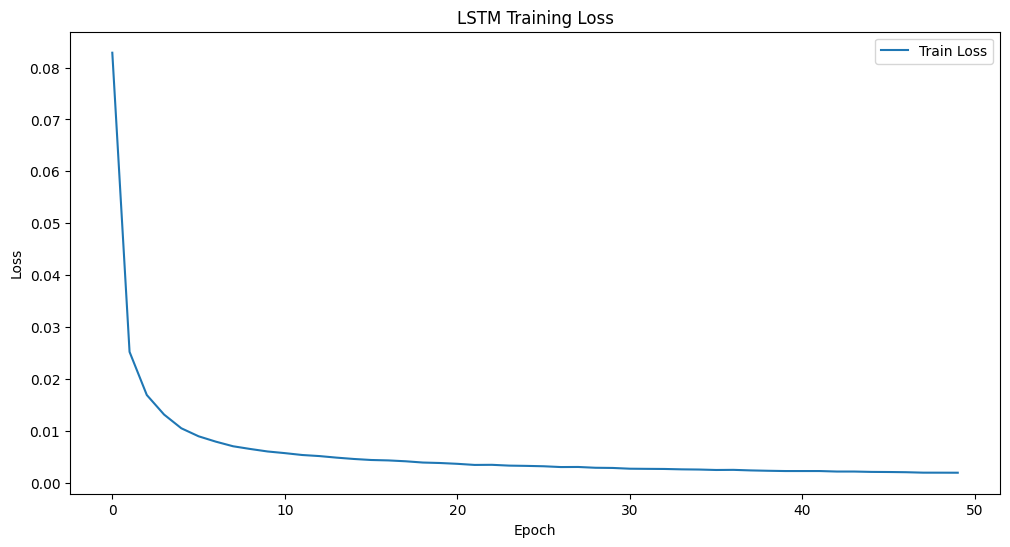


📊 Displaying sample stock predictions (5 stocks)...


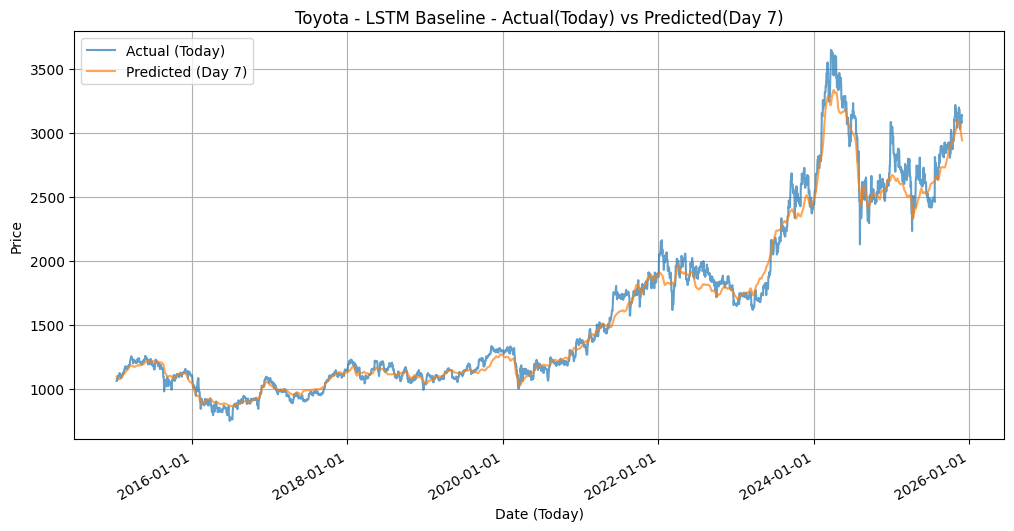

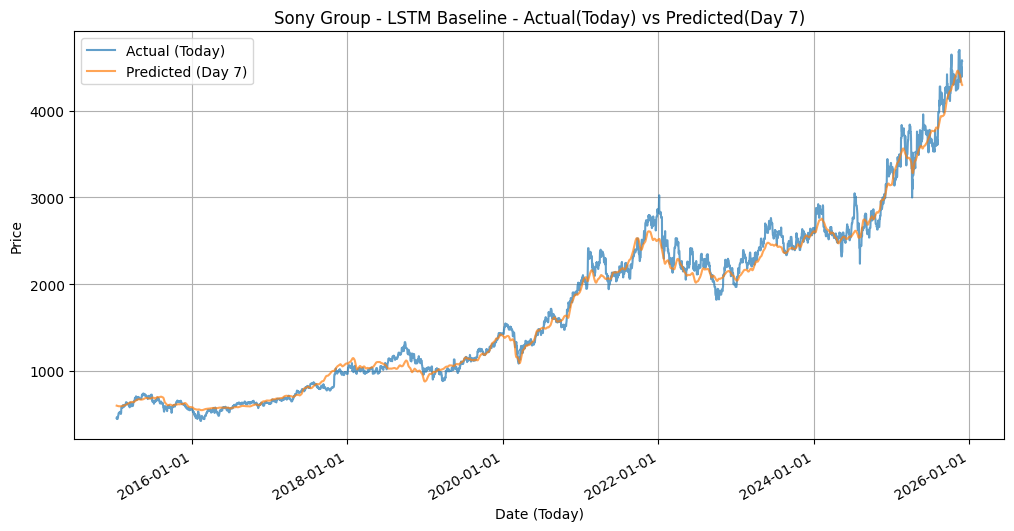

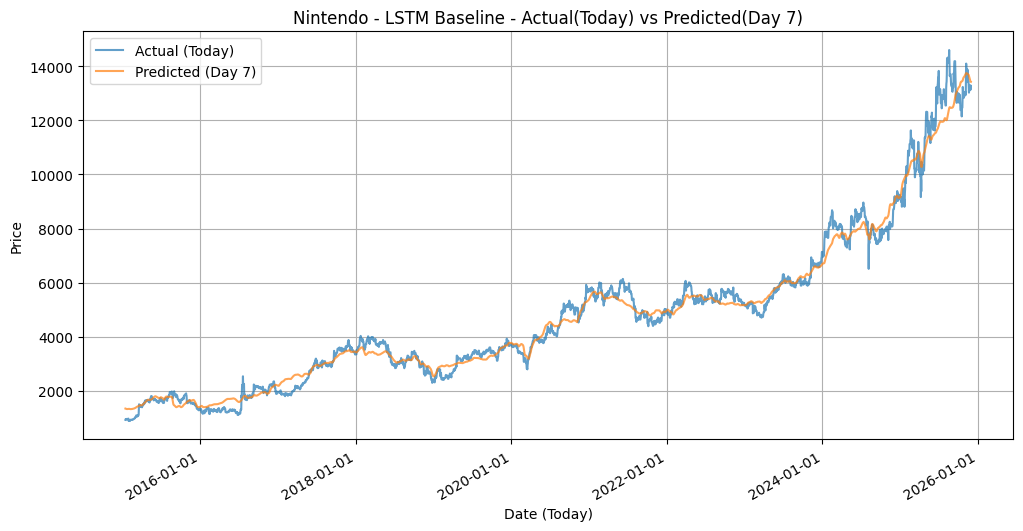

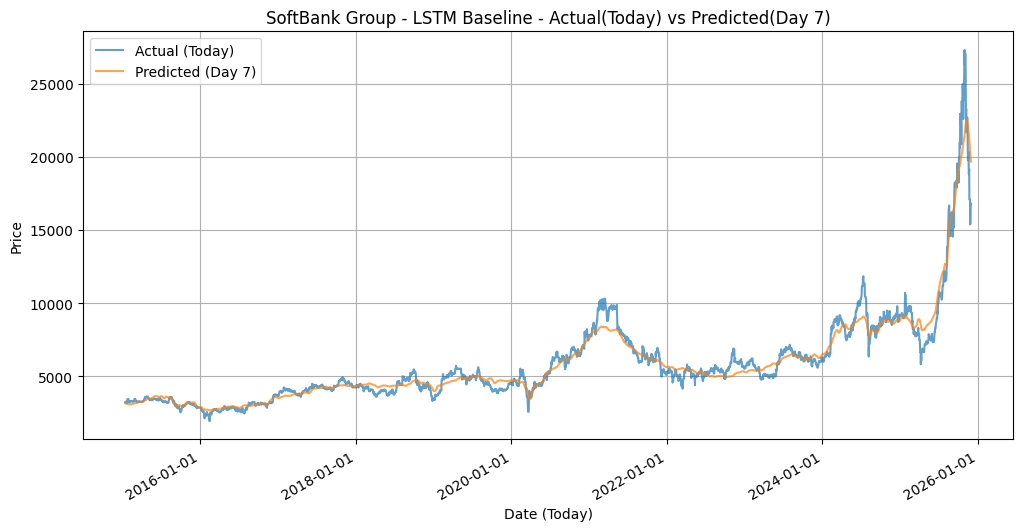

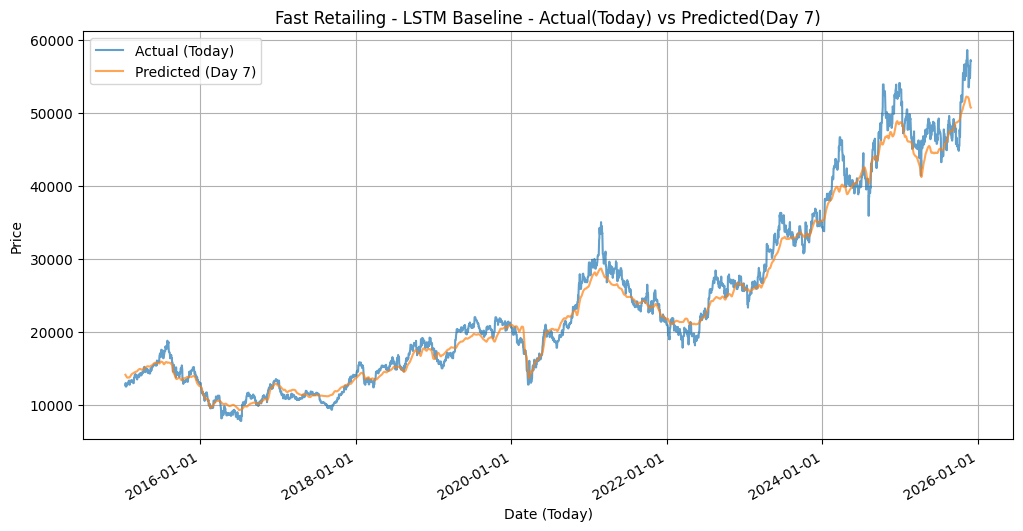


✅ All done! Check the downloaded 'predicted_stock_LSTM.csv' file.
   CSV contains: 날짜, and for each stock: Day1~Day7 predictions + Actual

💡 Next step: Run report.py with this CSV to compare with Transformer results!


In [1]:
"""
J-StockLab: 일본 주식 예측 - LSTM 베이스라인 모델

프로젝트: Nikkei 225 상위 20개 종목의 1~7일 후 주가 예측
모델: LSTM (Long Short-Term Memory)
- Input 1: 주식 데이터 (20개 종목)
- Input 2: 경제 지표 (FRED 18개 + yfinance 9개)
- Output: 각 종목별 1~7일 후 주가 (20종목 × 7일 = 140개 출력)

목적: Transformer 모델과의 성능 비교를 위한 딥러닝 베이스라인

작성자: 최정민, 김종수, 김용균
"""

# 파일 직접 업로드 방식 (Google Drive 불필요)
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LSTM, Concatenate
)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("=" * 80)
print("J-StockLab: Nikkei 225 Stock Prediction with LSTM (Baseline)")
print("=" * 80)

print("\n📁 Please upload 'total.csv' file...")
uploaded = files.upload()

print("\nLoading data...")
file_path = list(uploaded.keys())[0]
data = pd.read_csv(file_path, parse_dates=['날짜'])
data.sort_values(by='날짜', inplace=True)
print(f"Data loaded: {len(data)} rows, {len(data.columns)} columns")
print(f"Date range: {data['날짜'].min()} ~ {data['날짜'].max()}")

print("\nHandling missing values and filtering invalid data...")
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')
data.dropna(inplace=True)
print(f"After cleaning: {len(data)} rows")

# 하이퍼파라미터 (Transformer와 동일하게 유지)
forecast_horizon = 7  # 예측 기간 (1~7일 후를 예측)
lookback = 90  # 과거 90일 데이터 사용
num_forecast_days = 7  # 예측할 일수 (1일, 2일, ..., 7일)
epochs = 50
batch_size = 32
learning_rate = 0.0001

# Nikkei 225 상위 20개 종목 (시가총액 기준) - 영문명
target_columns = [
    'Toyota', 'SoftBank Group', 'Mitsubishi UFJ Financial', 'Sony Group',
    'Hitachi', 'Fast Retailing', 'SMFG', 'Nintendo',
    'Tokyo Electron', 'Advantest', 'Mitsubishi Heavy Ind', 'Mitsubishi Corp',
    'Keyence', 'Chugai Pharma', 'ITOCHU', 'Mizuho Financial',
    'NTT', 'Mitsui & Co', 'Recruit Holdings', 'Tokio Marine'
]

# 경제 지표: FRED 18개 + yfinance 9개 = 총 27개
economic_features = [
    # === 일본 경제 지표 (8개) ===
    '일본 실질 GDP', '일본 실업률', '일본 10년 국채 수익률',
    '일본 3개월 은행간 금리', '일본 총산업생산', '일본 무역수지',
    '일본 소비자 신뢰지수', '일본은행 총자산',

    # === 미국 경제 지표 (10개) ===
    '미국 10년 기대 인플레이션율', '미국 장단기 금리차', '미국 기준금리',
    '미국 2년 만기 국채 수익률', '미국 10년 만기 국채 수익률',
    '미시간대 소비자 심리지수', '미국 실업률', '미국 소비자 물가지수',
    '미국 GDP 성장률', '미국 금융스트레스지수',

    # === yfinance 시장 지표 (9개) ===
    '닛케이 225', '닛케이 300', 'TOPIX ETF',
    'S&P 500 지수', '나스닥 종합지수',
    'VIX 지수', '금 가격', '달러 인덱스', '엔/달러 환율'
]

print(f"\nTarget stocks: {len(target_columns)} stocks")
print(f"Economic features: {len(economic_features)} indicators")
print(f"  - Japan FRED: 8 indicators")
print(f"  - US FRED: 10 indicators")
print(f"  - yfinance: 9 indicators")

print("\nScaling data...")
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

data_scaled = data.copy()
stock_scaler = MinMaxScaler()
econ_scaler = MinMaxScaler()

data_scaled[target_columns] = stock_scaler.fit_transform(data[target_columns])
data_scaled[economic_features] = econ_scaler.fit_transform(data[economic_features])

print(f"Train/Test split: {train_size} / {len(data) - train_size} ({train_size/len(data)*100:.1f}% / {(1-train_size/len(data))*100:.1f}%)")

print(f"\nCreating sequences...")
print(f"Lookback window: {lookback} days")
print(f"Forecast horizon: {forecast_horizon} days")

# 훈련 데이터 생성 (1~7일 후 모두 예측)
X_stock_train = []
X_econ_train = []
y_train = []

for i in range(lookback, len(data_scaled) - forecast_horizon):
    X_stock_seq = data_scaled[target_columns].iloc[i - lookback:i].to_numpy()
    X_econ_seq = data_scaled[economic_features].iloc[i - lookback:i].to_numpy()
    # 1일 후 ~ 7일 후까지의 주가를 모두 타겟으로 설정
    y_vals = []
    for day in range(1, num_forecast_days + 1):
        y_vals.append(data_scaled[target_columns].iloc[i + day].to_numpy())
    y_val = np.concatenate(y_vals)  # (20*7=140,) 형태로 flatten
    X_stock_train.append(X_stock_seq)
    X_econ_train.append(X_econ_seq)
    y_train.append(y_val)

X_stock_train = np.array(X_stock_train)
X_econ_train = np.array(X_econ_train)
y_train = np.array(y_train)

print(f"Training data shape:")
print(f"  X_stock: {X_stock_train.shape} (samples, lookback, stocks)")
print(f"  X_econ: {X_econ_train.shape} (samples, lookback, indicators)")
print(f"  y: {y_train.shape} (samples, stocks × days = {len(target_columns)} × {num_forecast_days})")

# 전체 예측 데이터 생성
X_stock_full = []
X_econ_full = []
for i in range(lookback, len(data_scaled)):
    X_stock_seq = data_scaled[target_columns].iloc[i - lookback:i].to_numpy()
    X_econ_seq = data_scaled[economic_features].iloc[i - lookback:i].to_numpy()
    X_stock_full.append(X_stock_seq)
    X_econ_full.append(X_econ_seq)

X_stock_full = np.array(X_stock_full)
X_econ_full = np.array(X_econ_full)


# LSTM Dual Input 모델 정의
def build_lstm_dual_input(stock_shape, econ_shape, target_size):
    """
    LSTM 기반 Dual Input 모델
    Transformer와 비슷한 구조로 stock stream과 economic stream을 분리
    """
    # Stock stream
    stock_inputs = Input(shape=stock_shape, name='stock_input')
    stock_lstm = LSTM(64, return_sequences=True)(stock_inputs)
    stock_lstm = Dropout(0.2)(stock_lstm)
    stock_lstm = LSTM(64, return_sequences=False)(stock_lstm)
    stock_lstm = Dropout(0.2)(stock_lstm)
    stock_dense = Dense(64, activation='relu')(stock_lstm)

    # Economic stream
    econ_inputs = Input(shape=econ_shape, name='econ_input')
    econ_lstm = LSTM(64, return_sequences=True)(econ_inputs)
    econ_lstm = Dropout(0.2)(econ_lstm)
    econ_lstm = LSTM(64, return_sequences=False)(econ_lstm)
    econ_lstm = Dropout(0.2)(econ_lstm)
    econ_dense = Dense(64, activation='relu')(econ_lstm)

    # Merge streams
    merged = Concatenate()([stock_dense, econ_dense])
    merged = Dense(128, activation='relu')(merged)
    merged = Dropout(0.2)(merged)
    outputs = Dense(target_size)(merged)

    return Model(inputs=[stock_inputs, econ_inputs], outputs=outputs)


print("\n" + "=" * 80)
print("Building LSTM Dual Input Model (Baseline)...")
print("=" * 80)

stock_shape = (lookback, len(target_columns))
econ_shape = (lookback, len(economic_features))

print(f"\nModel architecture:")
print(f"  Stock Input: {stock_shape}")
print(f"  Economic Input: {econ_shape}")
print(f"  LSTM Layers: 2 layers each stream (64 units)")
print(f"  Output: {len(target_columns) * num_forecast_days} values ({len(target_columns)} stocks × {num_forecast_days} days)")

# 출력 크기: 20종목 × 7일 = 140
target_size = len(target_columns) * num_forecast_days
model = build_lstm_dual_input(stock_shape, econ_shape, target_size)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
model.summary()

print("\n" + "=" * 80)
print(f"Training model... (Epochs: {epochs}, Batch size: {batch_size}, LR: {learning_rate})")
print("=" * 80)
history = model.fit([X_stock_train, X_econ_train], y_train, epochs=epochs, batch_size=batch_size, verbose=1)

print("\n" + "=" * 80)
print("Performing full predictions...")
print("=" * 80)
predicted_prices = model.predict([X_stock_full, X_econ_full], verbose=1)

# 예측값을 (samples, days, stocks) 형태로 reshape하여 inverse_transform 적용
pred_len = len(predicted_prices)
predicted_reshaped = predicted_prices.reshape(pred_len, num_forecast_days, len(target_columns))

# 각 day별로 inverse_transform 적용
predicted_prices_actual = np.zeros_like(predicted_reshaped)
for day in range(num_forecast_days):
    predicted_prices_actual[:, day, :] = stock_scaler.inverse_transform(predicted_reshaped[:, day, :])

print(f"Predictions generated: {pred_len} samples × {num_forecast_days} days × {len(target_columns)} stocks")

# 오늘 날짜들 (마지막 날짜까지 포함)
today_dates = data['날짜'].iloc[lookback : lookback + pred_len].values

# 오늘 실제 주가
actual_data_end = min(lookback + pred_len, len(data))
actual_full = data[target_columns].iloc[lookback:actual_data_end].values

# 만약 actual_full 길이가 pred_len보다 짧다면 부족한 부분을 NaN으로 채움
if actual_full.shape[0] < pred_len:
    nan_padding = np.full((pred_len - actual_full.shape[0], len(target_columns)), np.nan)
    actual_full = np.vstack([actual_full, nan_padding])

result_data = pd.DataFrame({'날짜': today_dates})

# 각 종목별로 Day1~Day7 예측값과 Actual 저장
for idx, col in enumerate(target_columns):
    # 1일 후 ~ 7일 후 예측값
    for day in range(1, num_forecast_days + 1):
        result_data[f'{col}_Day{day}'] = predicted_prices_actual[:, day - 1, idx]
    # 오늘 실제 주가
    result_data[f'{col}_Actual'] = actual_full[:, idx]

result_data['날짜'] = pd.to_datetime(result_data['날짜'], errors='coerce')
result_data['날짜'] = result_data['날짜'].dt.strftime('%Y-%m-%d')

output_file_path = 'predicted_stock_LSTM.csv'
result_data.to_csv(output_file_path, index=False)
print(f"\n" + "=" * 80)
print(f"✅ Predicted stock prices saved to: {output_file_path}")
print(f"   - Total predictions: {len(result_data)} rows")
print(f"   - Columns: {len(result_data.columns)} (날짜 + {len(target_columns)} stocks × ({num_forecast_days} days + 1 actual))")
print("=" * 80)

# 결과 파일 다운로드
print("\n📥 Downloading predicted_stock_LSTM.csv...")
files.download(output_file_path)

# Training Loss 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 대표 종목 5개만 그래프 출력
sample_stocks = ['Toyota', 'Sony Group', 'Nintendo', 'SoftBank Group', 'Fast Retailing']
print(f"\n📊 Displaying sample stock predictions ({len(sample_stocks)} stocks)...")
for col in sample_stocks:
    plt.figure(figsize=(12, 6))
    plt.plot(pd.to_datetime(result_data['날짜']), result_data[f'{col}_Actual'], label='Actual (Today)', alpha=0.7)
    plt.plot(pd.to_datetime(result_data['날짜']), result_data[f'{col}_Day7'], label='Predicted (Day 7)', alpha=0.7)
    plt.title(f'{col} - LSTM Baseline - Actual(Today) vs Predicted(Day 7)')
    plt.xlabel('Date (Today)')
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()

print("\n✅ All done! Check the downloaded 'predicted_stock_LSTM.csv' file.")
print(f"   CSV contains: 날짜, and for each stock: Day1~Day7 predictions + Actual")
print("\n💡 Next step: Run report.py with this CSV to compare with Transformer results!")


In [2]:
"""
J-StockLab: 일본 주식 예측 - 평가 리포트 및 매수/매도 추천

프로젝트: Nikkei 225 상위 20개 종목의 1~7일 후 주가 예측 평가
- 평가 지표: MAE, MSE, RMSE, MAPE, Accuracy (각 Day별)
- 상승/하락 분석 및 매수/매도 추천
- 파일 직접 업로드 방식 (Google Drive 불필요)

작성자: 최정민, 김종수, 김용균
"""

# 파일 직접 업로드 방식 (Google Drive 불필요)
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

######################
# (1) Evaluation Function
######################
def evaluate_predictions(data, target_columns, num_forecast_days):
    """
    실제값과 예측값을 비교하여 다양한 평가 지표를 계산합니다.
    각 Day(1~7일)별로 평가 지표를 계산합니다.

    - MAE (Mean Absolute Error): 평균 절대 오차
      (낮을수록 좋음, 원본 데이터와 동일한 단위)
    - MSE (Mean Squared Error): 평균 제곱 오차
      (낮을수록 좋음)
    - RMSE (Root Mean Squared Error): MSE의 제곱근
      (낮을수록 좋음, MAE와 함께 자주 사용됨)
    - MAPE (Mean Absolute Percentage Error): 평균 절대 백분율 오차
      (낮을수록 좋음, 백분율로 표현)
    - Accuracy (%): 정확도 (100 - MAPE)
    """

    metrics = []

    for col in target_columns:
        actual_col = f'{col}_Actual'

        # Actual 컬럼 존재 여부 확인
        if actual_col not in data.columns:
            print(f"Skipping {col}: Actual column not found in data")
            continue

        # 각 Day별로 평가 (Day7 기준으로 메인 평가)
        day_metrics = {}
        for day in range(1, num_forecast_days + 1):
            predicted_col = f'{col}_Day{day}'

            if predicted_col not in data.columns:
                continue

            # 예측값 및 실제값 추출
            predicted = data[predicted_col]
            # N일 후의 실제값과 비교하기 위해 shift 적용
            actual = data[actual_col].shift(-day)

            # 유효한 데이터만 사용 (NaN 제거)
            valid_idx = ~predicted.isna() & ~actual.isna()
            predicted_valid = predicted[valid_idx]
            actual_valid = actual[valid_idx]

            if len(predicted_valid) == 0:
                continue

            # 평가 지표 계산
            mae = mean_absolute_error(actual_valid, predicted_valid)
            mse = mean_squared_error(actual_valid, predicted_valid)
            rmse = mse ** 0.5
            mape = (abs((actual_valid - predicted_valid) / actual_valid).mean()) * 100
            accuracy = 100 - mape

            day_metrics[day] = {
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE': mape,
                'Accuracy': accuracy
            }

        if not day_metrics:
            print(f"Skipping {col}: No valid prediction/actual pairs.")
            continue

        # Day7 기준 메인 평가 + 전체 Day 평균
        avg_mape = np.mean([d['MAPE'] for d in day_metrics.values()])
        avg_accuracy = np.mean([d['Accuracy'] for d in day_metrics.values()])

        result = {
            'Stock': col,
            'MAE_Day7': day_metrics.get(7, {}).get('MAE', np.nan),
            'RMSE_Day7': day_metrics.get(7, {}).get('RMSE', np.nan),
            'MAPE_Day7 (%)': day_metrics.get(7, {}).get('MAPE', np.nan),
            'Accuracy_Day7 (%)': day_metrics.get(7, {}).get('Accuracy', np.nan),
            'Avg_MAPE (%)': avg_mape,
            'Avg_Accuracy (%)': avg_accuracy
        }

        metrics.append(result)

    return pd.DataFrame(metrics)

###############################
# (2) Future Rise Analysis
###############################
def analyze_rise_predictions(data, target_columns, num_forecast_days=7):
    """
    가장 최근 데이터 기준으로 1~7일 후 상승/하락 예측 분석
    - 마지막 행의 실제 주가와 예측 주가를 비교
    - 상승 확률(%) 계산 (Day7 기준)
    """

    last_row = data.iloc[-1]
    results = []

    for col in target_columns:
        last_actual_price = last_row.get(f'{col}_Actual', np.nan)
        # Day7 예측값을 Predicted Future Price로 사용 (기존 호환성 유지)
        predicted_future_price = last_row.get(f'{col}_Day{num_forecast_days}', np.nan)

        # 상승/하락 및 상승 확률 계산
        if pd.notna(last_actual_price) and pd.notna(predicted_future_price):
            predicted_rise = predicted_future_price > last_actual_price
            rise_probability = ((predicted_future_price - last_actual_price) / last_actual_price) * 100
        else:
            predicted_rise = np.nan
            rise_probability = np.nan

        result = {
            'Stock': col,
            'Last Actual Price': last_actual_price,
            'Predicted Future Price': predicted_future_price,
            'Predicted Rise': predicted_rise,
            'Rise Probability (%)': rise_probability
        }

        # 각 Day별 예측값 추가 (Day1 ~ Day7)
        for day in range(1, num_forecast_days + 1):
            result[f'Day{day}_Price'] = last_row.get(f'{col}_Day{day}', np.nan)

        results.append(result)

    return pd.DataFrame(results)

#######################################
# (3) Buy/Sell Recommendation and Analysis
#######################################
def generate_recommendation(row):
    """
    매수/매도 추천 로직:
    - 상승 예측 & 상승률 > 0% => BUY
    - 상승률 > 2% => STRONG BUY
    - 그 외 => SELL
    """
    rise_prob = row.get('Rise Probability (%)', 0)
    predicted_rise = row.get('Predicted Rise', False)

    if pd.isna(rise_prob) or pd.isna(predicted_rise):
        return "No Data"

    if predicted_rise and rise_prob > 0:
        if rise_prob > 2:
            return "STRONG BUY"
        else:
            return "BUY"
    else:
        return "SELL"

def generate_analysis(row):
    """
    각 종목에 대한 간단한 분석 코멘트 생성
    """
    stock_name = row['Stock']
    rise_prob = row.get('Rise Probability (%)', 0)
    predicted_rise = row.get('Predicted Rise', False)

    if pd.isna(rise_prob) or pd.isna(predicted_rise):
        return f"{stock_name}: Not enough data"

    if predicted_rise:
        return f"{stock_name} is expected to rise by about {rise_prob:.2f}%. Consider buying or holding."
    else:
        return f"{stock_name} is expected to fall by about {-rise_prob:.2f}%. A cautious approach is recommended."

#######################
# (4) Main Code
#######################
print("=" * 80)
print("J-StockLab: Nikkei 225 Stock Prediction Evaluation")
print("=" * 80)

print("\n📁 Please upload 'predicted_stock.csv' file...")
uploaded = files.upload()

print("\nLoading predicted stock data...")
file_path = list(uploaded.keys())[0]  # 업로드된 파일명 자동 인식
data = pd.read_csv(file_path, parse_dates=['날짜'])
print(f"Data loaded: {len(data)} rows, {len(data.columns)} columns")
print(f"Date range: {data['날짜'].min()} ~ {data['날짜'].max()}")

# Nikkei 225 상위 20개 종목 (영문명)
target_columns = [
    'Toyota', 'SoftBank Group', 'Mitsubishi UFJ Financial', 'Sony Group',
    'Hitachi', 'Fast Retailing', 'SMFG', 'Nintendo',
    'Tokyo Electron', 'Advantest', 'Mitsubishi Heavy Ind', 'Mitsubishi Corp',
    'Keyence', 'Chugai Pharma', 'ITOCHU', 'Mizuho Financial',
    'NTT', 'Mitsui & Co', 'Recruit Holdings', 'Tokio Marine'
]

num_forecast_days = 7  # 예측 일수 (1~7일)

print(f"\nTarget stocks: {len(target_columns)} stocks")
print(f"Forecast days: 1~{num_forecast_days} days\n")

# 1) 모델 평가
print("=" * 80)
print("Step 1: Evaluating prediction accuracy...")
print("=" * 80)
evaluation_results = evaluate_predictions(data, target_columns, num_forecast_days)
print("\n============ Evaluation Results ============")
print(evaluation_results.to_string(index=False))

# 2) 미래 상승/하락 분석
print("\n" + "=" * 80)
print("Step 2: Analyzing future price movements...")
print("=" * 80)
rise_results = analyze_rise_predictions(data, target_columns, num_forecast_days)
print("\n============ Rise Predictions ============")
print(rise_results.to_string(index=False))

# 3) 데이터프레임 병합 (평가 지표 + 상승 분석)
print("\n" + "=" * 80)
print("Step 3: Generating recommendations...")
print("=" * 80)
final_results = pd.merge(evaluation_results, rise_results, on='Stock', how='outer')

# 4) 상승 확률 기준 내림차순 정렬
final_results = final_results.sort_values(by='Rise Probability (%)', ascending=False)

# 5) 매수/매도 추천 및 분석 생성
final_results['Recommendation'] = final_results.apply(generate_recommendation, axis=1)
final_results['Analysis'] = final_results.apply(generate_analysis, axis=1)

# 컬럼 순서 재정렬 (기본 컬럼 + Day별 가격)
base_columns = [
    'Stock',
    'MAE_Day7', 'RMSE_Day7', 'MAPE_Day7 (%)', 'Accuracy_Day7 (%)',
    'Avg_MAPE (%)', 'Avg_Accuracy (%)',
    'Last Actual Price', 'Predicted Future Price', 'Predicted Rise', 'Rise Probability (%)',
    'Recommendation', 'Analysis'
]
# Day별 가격 컬럼 추가
day_price_columns = [f'Day{day}_Price' for day in range(1, num_forecast_days + 1)]
column_order = base_columns + day_price_columns
# 존재하는 컬럼만 선택
column_order = [col for col in column_order if col in final_results.columns]
final_results = final_results[column_order]

# 6) CSV 파일로 저장
output_file_path = 'final_stock_analysis.csv'
final_results.to_csv(output_file_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Final analysis saved to: {output_file_path}")
print(f"   - Total stocks analyzed: {len(final_results)} stocks")
print(f"   - Columns: {len(final_results.columns)}")

# 7) 결과 파일 다운로드
print("\n📥 Downloading final_stock_analysis.csv...")
files.download(output_file_path)

# 8) 최종 리포트 출력
print("\n" + "=" * 80)
print("=============== Final Report ===============")
print("=" * 80)
print(final_results.to_string(index=False))

# 9) 요약 통계
print("\n" + "=" * 80)
print("=============== Summary Statistics ===============")
print("=" * 80)
print(f"\nTotal stocks analyzed: {len(final_results)}")
print(f"Average Accuracy (Day7): {final_results['Accuracy_Day7 (%)'].mean():.2f}%")
print(f"Average MAPE (Day7): {final_results['MAPE_Day7 (%)'].mean():.2f}%")
print(f"Average Accuracy (All Days): {final_results['Avg_Accuracy (%)'].mean():.2f}%")
print(f"\nRecommendation Distribution:")
print(final_results['Recommendation'].value_counts())
print(f"\nTop 5 stocks by Rise Probability:")
print(final_results[['Stock', 'Rise Probability (%)', 'Recommendation']].head(5).to_string(index=False))

print("\n" + "=" * 80)
print("✅ All done! Check the downloaded 'final_stock_analysis.csv' file.")
print("=" * 80)


J-StockLab: Nikkei 225 Stock Prediction Evaluation

📁 Please upload 'predicted_stock.csv' file...


Saving predicted_stock_LSTM.csv to predicted_stock_LSTM (1).csv

Loading predicted stock data...
Data loaded: 3972 rows, 161 columns
Date range: 2015-01-14 00:00:00 ~ 2025-11-28 00:00:00

Target stocks: 20 stocks
Forecast days: 1~7 days

Step 1: Evaluating prediction accuracy...

============ Evaluation Results ============
                   Stock    MAE_Day7   RMSE_Day7  MAPE_Day7 (%)  Accuracy_Day7 (%)  Avg_MAPE (%)  Avg_Accuracy (%)
                  Toyota   64.577502   93.738738       3.748814          96.251186      3.764237         96.235763
          SoftBank Group  444.054405  718.557946       7.211891          92.788109      7.021758         92.978242
Mitsubishi UFJ Financial   34.217546   51.885851       4.524612          95.475388      4.333080         95.666920
              Sony Group   83.317949  113.340036       5.239910          94.760090      5.291175         94.708825
                 Hitachi   84.115972  135.604552       6.279586          93.720414      6.034702   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=============== Final Report ===============
                   Stock    MAE_Day7   RMSE_Day7  MAPE_Day7 (%)  Accuracy_Day7 (%)  Avg_MAPE (%)  Avg_Accuracy (%)  Last Actual Price  Predicted Future Price  Predicted Rise  Rise Probability (%) Recommendation                                                                                         Analysis  Day1_Price  Day2_Price  Day3_Price  Day4_Price  Day5_Price  Day6_Price  Day7_Price
          SoftBank Group  444.054405  718.557946       7.211891          92.788109      7.021758         92.978242       16825.000000             19684.59800            True             16.996125     STRONG BUY                  SoftBank Group is expected to rise by about 17.00%. Consider buying or holding. 20063.42800 19898.97700 19308.88700  19919.7200 20189.16200 19965.98600 19684.59800
            Tokio Marine  107.884448  169.696635       4.639858          95.360142      4.657981         95.342019        5509.000000              5813.91600            T